In [1]:
from pathlib import Path
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
truth_csv_path = "/Users/furkan/projects/cpak-prediction/data/cpak-grnd-truth.csv"

# enter corresponding orthopedic_metrics.json file
inference_json_path = "/Users/furkan/projects/cpak-prediction/notebooks/out/inference/sh14-ep1000/orthopedic_metrics.json"

output_folder = "/Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000"

### Handle truth angles

In [3]:
def truth_id_normalizer(hasta: str) -> str:
    """
    input: 4000L  veya  4075l  veya  98512019948r
    output: 4000_l
    """
    hasta = str(hasta).strip()
    side = hasta[-1].lower()      # son karakter taraf bilgisi (l / r)
    base = hasta[:-1]
    return f"{base}_{side}"

In [4]:
# CSV'den ground truth oku
# kolonlar: 0=HASTA, 1=GRAFİ (1 UZUNLUK / 2 AP), 2=MPTA (tibia), 3=LDFA (femur), 8=SINIFLAMA (CPAK Tip)
truth_df = pd.read_csv(truth_csv_path)

truth_angles = {}
for _, row in truth_df.iterrows():
	hasta = str(row.iloc[0]).strip()
	grafi = str(row.iloc[1]).strip()

	# sadece UZUNLUK grafilerini (GRAFİ=1) al
	if grafi not in ("1", "1.0"):
		continue
	# geçersiz / başlık satırlarını atla
	if not hasta or hasta[-1].lower() not in ("l", "r"):
		continue

	key = truth_id_normalizer(hasta)
	truth_angles[key] = {
		"femur": row.iloc[3],              # LDFA
		"tibia": row.iloc[2],              # MPTA
		"type": str(row.iloc[8]).strip(),  # SINIFLAMA (CPAK Tip 1-9)
	}

truth_angles  # '4075_l': {'femur': 88, 'tibia': 81, 'type': 'Tip 1'}

{'4000_l': {'femur': 90, 'tibia': 85, 'type': 'Tip 1'},
 '4000_r': {'femur': 90, 'tibia': 86, 'type': 'Tip 1'},
 '4001_r': {'femur': 98, 'tibia': 72, 'type': 'Tip 1'},
 '4001_l': {'femur': 92, 'tibia': 83, 'type': 'Tip 1'},
 '4002_l': {'femur': 95, 'tibia': 83, 'type': 'Tip 4'},
 '4002_r': {'femur': 85, 'tibia': 85, 'type': 'Tip 2'},
 '4003_l': {'femur': 94, 'tibia': 87, 'type': 'Tip 4'},
 '4003_r': {'femur': 90, 'tibia': 84, 'type': 'Tip 1'},
 '4004_r': {'femur': 93, 'tibia': 81, 'type': 'Tip 1'},
 '4005_l': {'femur': 93, 'tibia': 83, 'type': 'Tip 1'},
 '4005_r': {'femur': 93, 'tibia': 83, 'type': 'Tip 1'},
 '4006_l': {'femur': 90, 'tibia': 82, 'type': 'Tip 1'},
 '4006_r': {'femur': 94, 'tibia': 79, 'type': 'Tip 1'},
 '4007_l': {'femur': 90, 'tibia': 78, 'type': 'Tip 1'},
 '4007_r': {'femur': 92, 'tibia': 78, 'type': 'Tip 1'},
 '4008_r': {'femur': 95, 'tibia': 86, 'type': 'Tip 4'},
 '4009_l': {'femur': 90, 'tibia': 86, 'type': 'Tip 1'},
 '4009_r': {'femur': 91, 'tibia': 83, 'type': 'T

### Handle inference angles

In [5]:
def inference_file_name_normalizer(filename: str) -> str:
	"""
	input: 4000.l.png
	output: 4000_l
	"""

	# Dosya adını ve uzantılarını ayırır (örn: 4000.l.png -> 4000.l)
	name_without_extension = Path(filename).stem

	# Noktayı alt tire ile değiştirir
	formatted_name = name_without_extension.replace(".", "_")

	return formatted_name

In [6]:
orto_metrics = {}
inference_angles = {}
with open(inference_json_path, "r", encoding="utf-8") as f:
	json_text = f.read()
	orto_metrics = json.loads(json_text)

	for key in orto_metrics.keys():
		new_key = inference_file_name_normalizer(key)
		inference_angles[new_key] = {
			"femur": orto_metrics[key]["femur_mech_angle_notch"],
			"tibia": orto_metrics[key]["tibia_mech_angle_inter"],
		}

inference_angles  # '4075_l': {'femur': 86.57, 'tibia': 82.10}

{'10105873454_l': {'femur': 86.90675932474186, 'tibia': 95.30102128526303},
 '10105873454_r': {'femur': 88.8001644076592, 'tibia': 88.58371386280653},
 '10178557442_l': {'femur': 94.49288490683571, 'tibia': 90.55019504635256},
 '10178557442_r': {'femur': 128.20329683833813, 'tibia': 86.97328926557299},
 '10373685384_l': {'femur': 90.30739051539143, 'tibia': 87.59650375854625},
 '10373685384_r': {'femur': 89.38530320017412, 'tibia': 86.42373248729267},
 '11682274_l': {'femur': 89.96390967251976, 'tibia': 83.4092480952638},
 '11682274_r': {'femur': 92.0533457153816, 'tibia': 85.44934725223082},
 '15461812840_l': {'femur': 92.65776626044341, 'tibia': 82.96298183406934},
 '15461812840_r': {'femur': 111.4222217482332, 'tibia': 88.16625610329702},
 '16153402226_l': {'femur': 90.75700131763337, 'tibia': 84.84607125171095},
 '16153402226_r': {'femur': 90.04370756065505, 'tibia': 82.53041181210529},
 '16414661324_l': {'femur': 94.95158992553802, 'tibia': 83.94670773940108},
 '16414661324_r': {'

In [7]:
# CPAK sınıflandırma (CSV eşikleriyle birebir doğrulandı)
#   alignment (MPTA-LDFA): < -2 varus, > 2 valgus, aksi nötr
#   joint line (MPTA+LDFA): < 177 apex distal, > 183 apex proksimal, aksi nötr
CPAK_GRID = {
	("varus", "apex distal"):    "Tip 1", ("nötr", "apex distal"):    "Tip 2", ("valgus", "apex distal"):    "Tip 3",
	("varus", "nötr"):           "Tip 4", ("nötr", "nötr"):           "Tip 5", ("valgus", "nötr"):           "Tip 6",
	("varus", "apex proksimal"): "Tip 7", ("nötr", "apex proksimal"): "Tip 8", ("valgus", "apex proksimal"): "Tip 9",
}


def alignment_category(mpta, ldfa):
	d = mpta - ldfa
	if d < -2:
		return "varus"
	if d > 2:
		return "valgus"
	return "nötr"


def jointline_category(mpta, ldfa):
	s = mpta + ldfa
	if s < 177:
		return "apex distal"
	if s > 183:
		return "apex proksimal"
	return "nötr"


def cpak_type(mpta, ldfa):
	return CPAK_GRID[(alignment_category(mpta, ldfa), jointline_category(mpta, ldfa))]

## Create all values dataframe

In [8]:
def create_comparison_df(gt_dict, pred_dict, output_path):
    """
    Creates a comparison DataFrame: per-knee femur/tibia angles, their errors,
    and the CPAK classification (ground truth vs predicted).
    """
    common_keys = sorted(list(set(gt_dict.keys()) & set(pred_dict.keys())))

    output_folder = os.path.dirname(output_path)
    if output_folder and not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)

    data = []
    for key in common_keys:
        row = {'id': key}

        # --- FEMUR (LDFA) ---
        try:
            f_gt_raw = gt_dict[key].get('femur')
            f_gt_val = float(f_gt_raw) if f_gt_raw is not None else None
        except (ValueError, TypeError):
            f_gt_val = None

        f_pred = pred_dict[key].get('femur')
        f_err = abs(f_gt_val - f_pred) if (f_gt_val is not None and f_pred is not None) else None

        # --- TIBIA (MPTA) ---
        try:
            t_gt_raw = gt_dict[key].get('tibia')
            t_gt_val = float(t_gt_raw) if t_gt_raw is not None else None
        except (ValueError, TypeError):
            t_gt_val = None

        t_pred = pred_dict[key].get('tibia')
        t_err = abs(t_gt_val - t_pred) if (t_gt_val is not None and t_pred is not None) else None

        # --- CPAK CLASSIFICATION ---
        gt_type = gt_dict[key].get('type')
        pred_type = cpak_type(t_pred, f_pred) if (f_pred is not None and t_pred is not None) else None
        type_correct = (gt_type == pred_type) if (gt_type and pred_type) else None

        row.update({
            'f_gt': f_gt_val,
            'f_pred': f_pred,
            'f_err': f_err,
            't_gt': t_gt_val,
            't_pred': t_pred,
            't_err': t_err,
            'gt_type': gt_type,
            'pred_type': pred_type,
            'type_correct': type_correct,
        })

        data.append(row)

    df = pd.DataFrame(data)

    df.to_csv(output_path, index=False, encoding="utf-8")

    print(f"File saved: {output_path}")
    return df

output_path = output_folder + "/angles.csv"
all_df = create_comparison_df(truth_angles, inference_angles, output_path)
all_df.head()

File saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/angles.csv


,id,f_gt,f_pred,f_err,t_gt,t_pred,t_err,gt_type,pred_type,type_correct
0,10105873454_r,87.0,88.800164,1.800164,97.0,88.583714,8.416286,Tip 9,Tip 5,False
1,10178557442_l,92.0,94.492885,2.492885,90.0,90.550195,0.550195,Tip 5,Tip 7,False
2,10178557442_r,92.0,128.203297,36.203297,91.0,86.973289,4.026711,Tip 5,Tip 7,False
3,10373685384_r,90.0,89.385303,0.614697,87.0,86.423732,0.576268,Tip 4,Tip 1,False
4,15461812840_l,93.0,92.657766,0.342234,84.0,82.962982,1.037018,Tip 4,Tip 1,False


## Calculate metrics and save as json

In [9]:
def calculate_and_save_metrics(df, output_folder):
    """Calculates femur/tibia angle metrics and the CPAK classification accuracy, saves as JSON."""
    metrics = {}

    for prefix, bone_name in [('f', 'femur'), ('t', 'tibia')]:
        y_true = df[f'{prefix}_gt']
        y_pred = df[f'{prefix}_pred']

        # Filter out NaN values to prevent calculation errors
        mask = y_true.notnull() & y_pred.notnull()
        y_t = y_true[mask]
        y_p = y_pred[mask]

        if len(y_t) > 0:
            metrics[bone_name] = {
                'MAE': round(float(mean_absolute_error(y_t, y_p)), 3),
                'RMSE': round(float(np.sqrt(mean_squared_error(y_t, y_p))), 3),
                'R2': round(float(r2_score(y_t, y_p)), 3),
                'sample_count': int(len(y_t))
            }
        else:
            metrics[bone_name] = "No valid data"

    # CPAK classification accuracy
    cls = df[df['type_correct'].notnull()]
    total = int(len(cls))
    correct = int(cls['type_correct'].sum())
    metrics['classification'] = {
        'total': total,
        'correct': correct,
        'wrong': total - correct,
        'accuracy': round(correct / total * 100, 1) if total else 0.0,
    }

    # Save to JSON
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)

    file_path = os.path.join(output_folder, "metrics.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=4, ensure_ascii=False)

    print(f"Metrics saved: {file_path}")
    return metrics

calculate_and_save_metrics(all_df, output_folder)

Metrics saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/metrics.json


{'femur': {'MAE': 3.74, 'RMSE': 8.591, 'R2': -5.085, 'sample_count': 246},
 'tibia': {'MAE': 2.31, 'RMSE': 5.302, 'R2': -1.036, 'sample_count': 246},
 'classification': {'total': 246,
  'correct': 110,
  'wrong': 136,
  'accuracy': 44.7}}

## Visualization

In [10]:
def visualize_performance(df, output_folder):
    """Generates regression and residual plots for the femur (LDFA) and tibia (MPTA) angles."""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)

    sns.set_theme(style="whitegrid")

    for prefix, bone_name in [('f', 'Femur'), ('t', 'Tibia')]:
        # Create a figure with 2 columns (Regression and Error Distribution)
        plt.figure(figsize=(16, 7))

        # 1. Regression Plot
        plt.subplot(1, 2, 1)
        sns.regplot(
            data=df,
            x=f'{prefix}_gt',
            y=f'{prefix}_pred',
            scatter_kws={'alpha': 0.5},
            line_kws={'linestyle': '--'}
        )

        # Add a 45-degree ideal line
        min_val = df[f'{prefix}_gt'].min()
        max_val = df[f'{prefix}_gt'].max()
        plt.plot([min_val, max_val], [min_val, max_val], color='black', lw=2, label='Perfect Match')

        plt.title(f"{bone_name} - Prediction vs Ground Truth")
        plt.xlabel("Ground Truth (Degrees)")
        plt.ylabel("Model Prediction (Degrees)")
        plt.legend()

        # 2. Error Distribution (Residuals)
        plt.subplot(1, 2, 2)
        errors = df[f'{prefix}_gt'] - df[f'{prefix}_pred']
        sns.kdeplot(errors, fill=True, label="Error")
        plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
        plt.title(f"{bone_name} - Error Density (Residuals)")
        plt.xlabel("Error (Actual - Predicted)")
        plt.ylabel("Density")
        plt.legend()

        plt.tight_layout()
        save_path = os.path.join(output_folder, f"{bone_name.lower()}_comparison_graphs.png")
        plt.savefig(save_path, dpi=300)
        plt.close()
        print(f"Graph saved: {save_path}")

# Run visualization
visualize_performance(all_df, output_folder)

Graph saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/femur_comparison_graphs.png
Graph saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/tibia_comparison_graphs.png


In [11]:
def error_distribution(df, output_folder):
    """
    Builds distribution.json with two parts:
      - per-bone absolute angle-error bins (0.5 deg steps)
      - CPAK classification report: overall correct/wrong + per-type breakdown
        + the list of misclassified knees (gt vs predicted type).
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)

    # 1. Angle error bins
    bins = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, np.inf]
    labels = [
        "0.0 - 0.5", "0.5 - 1.0", "1.0 - 1.5", "1.5 - 2.0", 
        "2.0 - 2.5", "2.5 - 3.0", "3.0 - 3.5", "3.5 - 4.0", "> 4.0"
    ]

    final_report = {}

    for prefix, bone_name in [('f', 'Femur'), ('t', 'Tibia')]:
        range_col = f'{prefix}_range'
        df[range_col] = pd.cut(df[f'{prefix}_err'], bins=bins, labels=labels, include_lowest=True)

        bone_distribution = {}
        for label in labels:
            mask = df[range_col] == label
            matched_ids = df[mask]['id'].tolist()
            bone_distribution[label] = {
                "count": len(matched_ids),
                "percentage": f"{(len(matched_ids) / len(df)) * 100:.1f}%",
                "samples": matched_ids
            }
        final_report[bone_name] = bone_distribution

    # 2. CPAK classification report
    cls = df[df['type_correct'].notnull()]
    total = int(len(cls))
    correct = int(cls['type_correct'].sum())

    def type_sort_key(t):
        parts = str(t).split()
        return int(parts[-1]) if parts and parts[-1].isdigit() else 0

    per_type = {}
    for t in sorted(cls['gt_type'].dropna().unique(), key=type_sort_key):
        sub = cls[cls['gt_type'] == t]
        c = int(sub['type_correct'].sum())
        per_type[t] = {
            "gt_count": int(len(sub)),
            "correct": c,
            "wrong": int(len(sub)) - c,
            "accuracy": f"{(c / len(sub)) * 100:.1f}%" if len(sub) else "0.0%",
        }

    wrong_samples = [
        {"id": r['id'], "gt_type": r['gt_type'], "pred_type": r['pred_type']}
        for _, r in cls[~cls['type_correct'].astype(bool)].iterrows()
    ]

    final_report["Classification"] = {
        "total": total,
        "correct": correct,
        "wrong": total - correct,
        "accuracy": f"{(correct / total) * 100:.1f}%" if total else "0.0%",
        "per_type": per_type,
        "wrong_samples": wrong_samples,
    }

    # 3. Save to JSON
    output_path = os.path.join(output_folder, "distribution.json")
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_report, f, indent=4, ensure_ascii=False)

    print(f"Distribution saved: {output_path}")
    return final_report

all_df = error_distribution(all_df, output_folder)

Distribution saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/distribution.json


saved: /Users/furkan/projects/cpak-prediction/notebooks/out/test/sh14-ep1000/distribution_plot.png


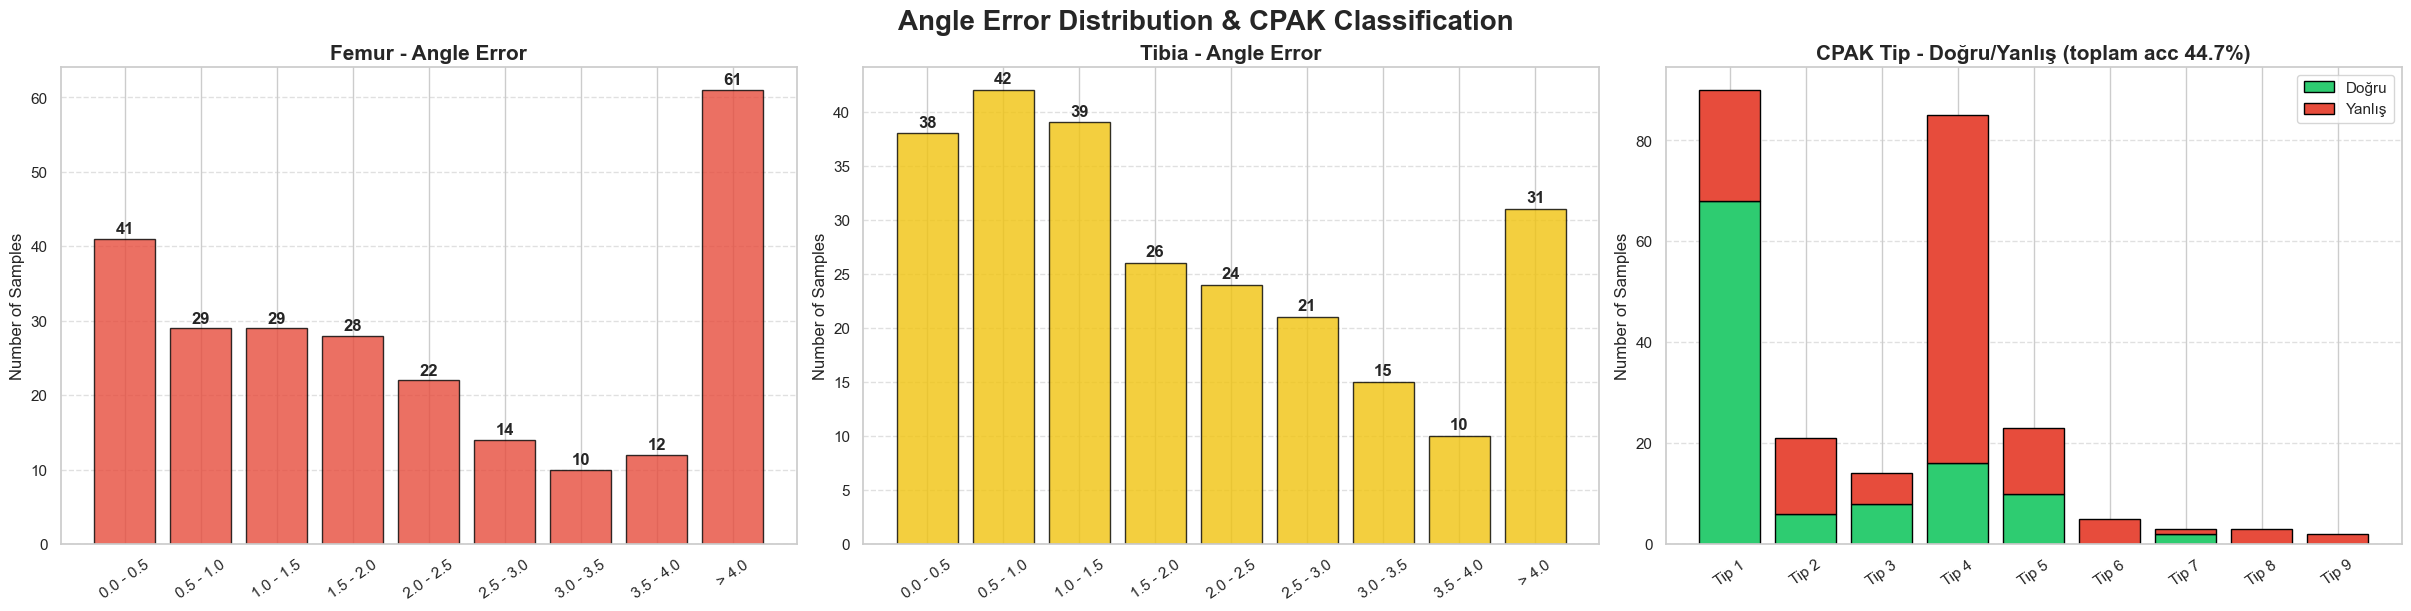

In [12]:
json_data = ""

with open(output_folder + "/distribution.json", "r") as f:
	json_data = json.loads(f.read())


def distribution_plot(data):
	fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
	fig.suptitle('Angle Error Distribution & CPAK Classification', fontsize=20, fontweight='bold')

	# 1-2. Femur / Tibia angle error bins
	for ax, (bone, color) in zip(axes[:2], [("Femur", "#e74c3c"), ("Tibia", "#f1c40f")]):
		sub_data = data[bone]
		labels = list(sub_data.keys())
		counts = [val["count"] for val in sub_data.values()]

		bars = ax.bar(labels, counts, color=color, edgecolor='black', alpha=0.8)
		ax.set_title(f"{bone} - Angle Error", fontsize=15, fontweight='bold')
		ax.set_ylabel("Number of Samples", fontsize=12)
		ax.tick_params(axis='x', rotation=35)
		ax.grid(axis='y', linestyle='--', alpha=0.6)

		for bar in bars:
			yval = bar.get_height()
			ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.3, int(yval), ha='center', va='bottom', fontweight='bold')

	# 3. CPAK type correct / wrong (stacked)
	cls = data["Classification"]
	per_type = cls["per_type"]
	types = sorted(per_type.keys(), key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else 0)
	correct = [per_type[t]["correct"] for t in types]
	wrong = [per_type[t]["wrong"] for t in types]

	ax = axes[2]
	ax.bar(types, correct, color="#2ecc71", edgecolor='black', label="Doğru")
	ax.bar(types, wrong, bottom=correct, color="#e74c3c", edgecolor='black', label="Yanlış")
	ax.set_title(f"CPAK Tip - Doğru/Yanlış (toplam acc {cls['accuracy']})", fontsize=15, fontweight='bold')
	ax.set_ylabel("Number of Samples", fontsize=12)
	ax.tick_params(axis='x', rotation=35)
	ax.grid(axis='y', linestyle='--', alpha=0.6)
	ax.legend()

	save_path = output_folder + "/" + "distribution_plot.png"
	plt.savefig(save_path, dpi=300)

	print("saved:", save_path)

distribution_plot(json_data)